# Notebook 04 — Visualisation & Business Insights

**Project:** Customer Churn ETL & Analytics Pipeline  
**Student:** Divyesh Joshi | MC24097 | MCA-II Sem IV  
**Institute:** IIMS Chinchwad, Pune — Savitribai Phule Pune University  

---

## Objective
This notebook produces all business visualisations and key insights:
- Revenue at risk analysis
- Churn drivers across all categorical features
- ML model performance charts
- Retention offer distribution
- Final project summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Load scored data (from pipeline) or raw data
SCORED = '../data/processed/churn_scored.csv'
RAW    = '../data/raw/Telco-Customer-Churn.csv'

if os.path.exists(SCORED):
    df = pd.read_csv(SCORED)
    print(f'Loaded scored data: {df.shape}')
    HAS_ML = 'ChurnProbability' in df.columns
else:
    df = pd.read_csv(RAW)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(df['TotalCharges'].median())
    df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
    HAS_ML = False
    print(f'Loaded raw data: {df.shape}')

print(f'ML scores available: {HAS_ML}')

Loaded scored data: (7043, 59)
ML scores available: True


## 1. Executive KPI Summary

In [2]:
total       = len(df)
churned     = int(df['Churn'].sum())
churn_rate  = churned / total * 100
rev_lost    = df[df['Churn']==1]['MonthlyCharges'].sum()
annual_lost = rev_lost * 12
avg_tenure  = df['tenure'].mean()

print('=== PROJECT KPI SUMMARY ===')
print(f'Total Customers        : {total:,}')
print(f'Churned Customers      : {churned:,} ({churn_rate:.1f}%)')
print(f'Retained Customers     : {total-churned:,} ({100-churn_rate:.1f}%)')
print(f'Monthly Revenue Lost   : Rs. {rev_lost:,.2f}')
print(f'Annual Revenue at Risk : Rs. {annual_lost:,.2f}')
print(f'Average Tenure         : {avg_tenure:.1f} months')

=== PROJECT KPI SUMMARY ===
Total Customers        : 7,043
Churned Customers      : 1,869 (26.5%)
Retained Customers     : 5,174 (73.5%)
Monthly Revenue Lost   : Rs. 139,130.85
Annual Revenue at Risk : Rs. 1,669,570.20
Average Tenure         : 32.4 months


## 2. Churn Across All Categorical Features

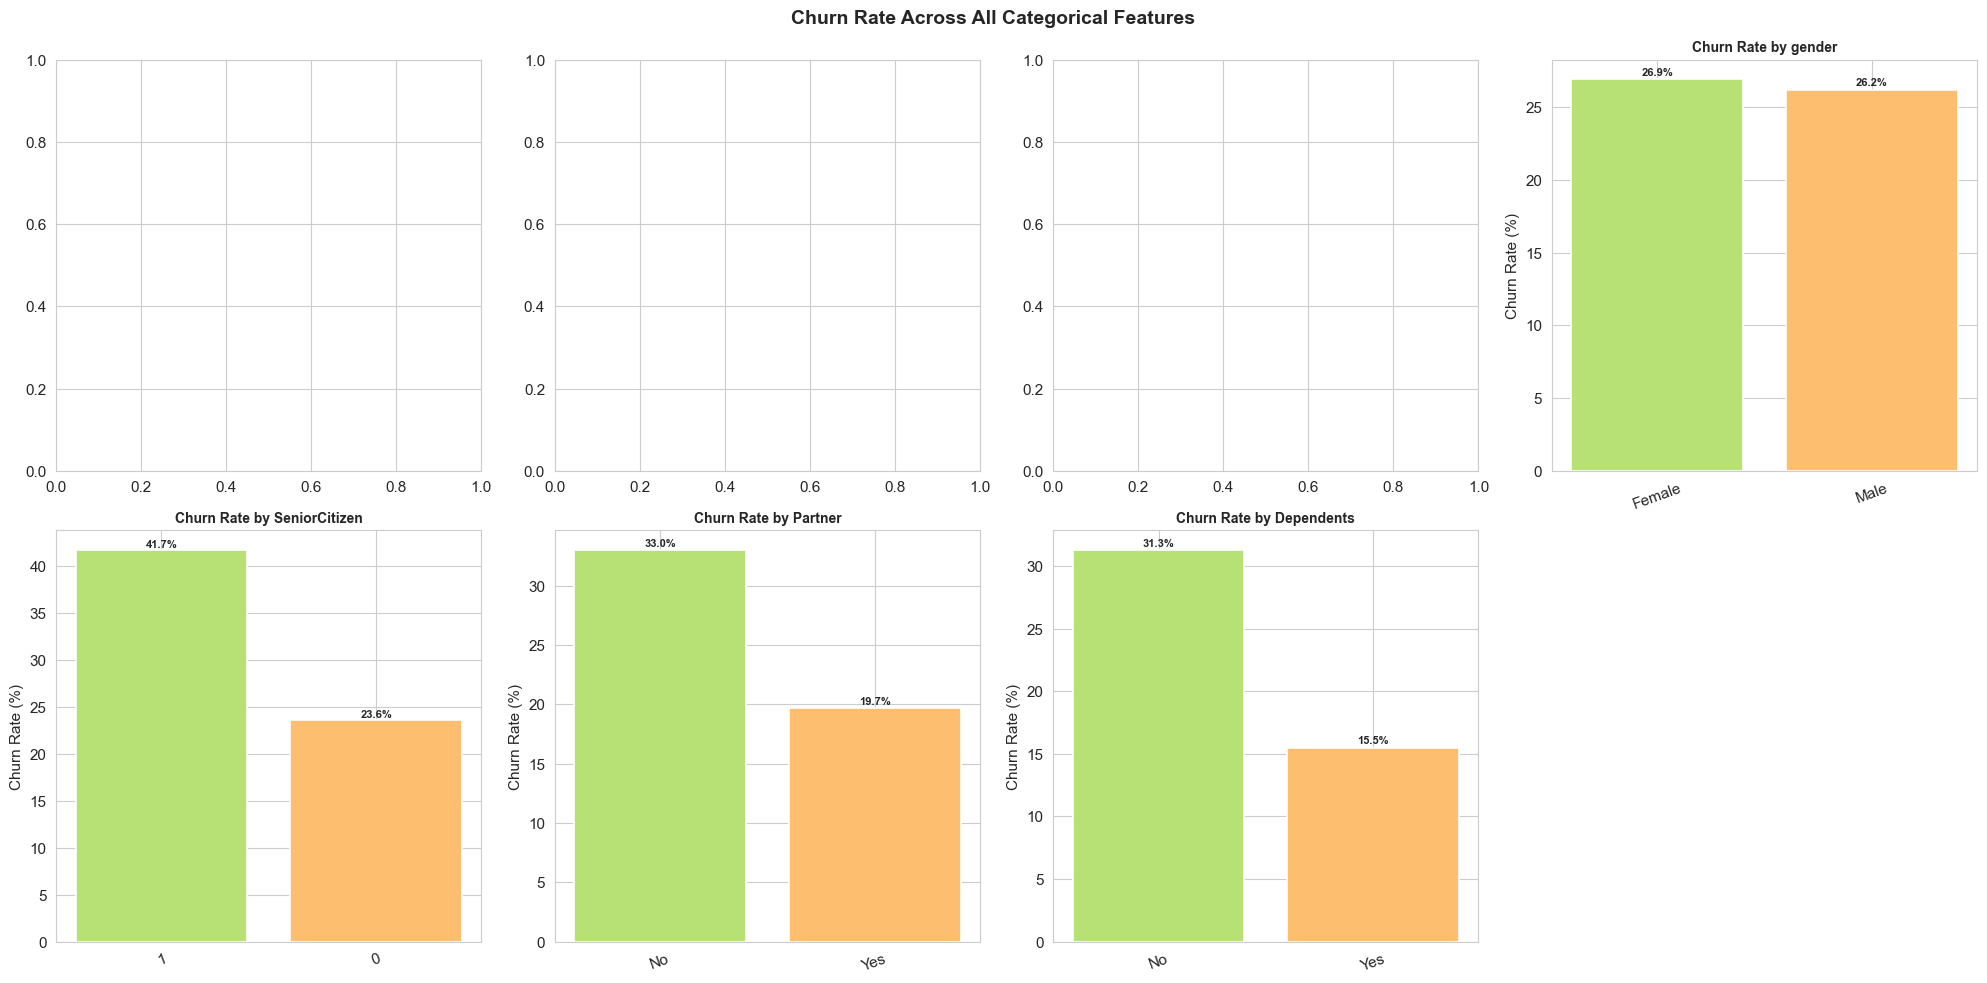

In [3]:
cat_features = ['Contract','InternetService','PaymentMethod',
                'gender','SeniorCitizen','Partner','Dependents']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    if feat not in df.columns: continue
    stats = (df.groupby(feat)['Churn']
               .agg(['sum','count'])
               .rename(columns={'sum':'Churned','count':'Total'}))
    stats['Rate'] = (stats['Churned'] / stats['Total'] * 100).round(1)
    stats = stats.sort_values('Rate', ascending=False)

    bars = axes[i].bar(stats.index.astype(str), stats['Rate'],
                       color=sns.color_palette('RdYlGn_r', len(stats)),
                       edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'Churn Rate by {feat}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, stats['Rate']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Churn Rate Across All Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Monthly Charges vs Churn (Boxplot + Violin)

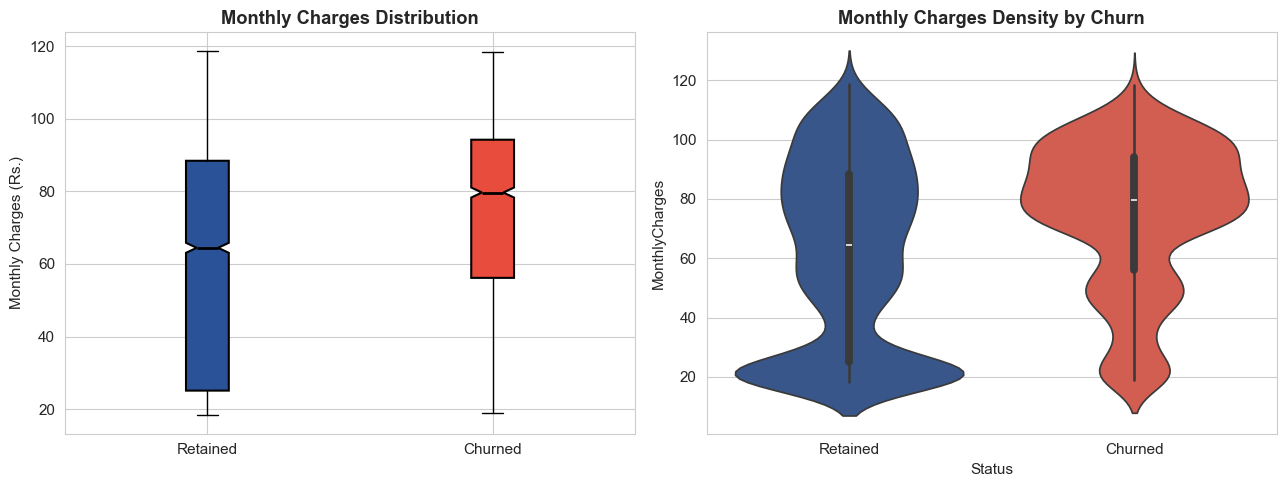

Churned median: Rs.79.65  |  Retained median: Rs.64.43


In [4]:
churn_labels = df['Churn'].map({0:'Retained', 1:'Churned'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
churned_mc  = df[df['Churn']==1]['MonthlyCharges']
retained_mc = df[df['Churn']==0]['MonthlyCharges']
bp = axes[0].boxplot([retained_mc, churned_mc], labels=['Retained','Churned'],
                      patch_artist=True, notch=True,
                      boxprops=dict(linewidth=1.5),
                      medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#2a5298')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_title('Monthly Charges Distribution', fontweight='bold')
axes[0].set_ylabel('Monthly Charges (Rs.)')

# Violin
plot_df = pd.DataFrame({'MonthlyCharges': df['MonthlyCharges'], 'Status': churn_labels})
sns.violinplot(data=plot_df, x='Status', y='MonthlyCharges', ax=axes[1],
               palette={'Retained':'#2a5298','Churned':'#e74c3c'}, inner='box')
axes[1].set_title('Monthly Charges Density by Churn', fontweight='bold')

plt.tight_layout(); plt.show()
print(f'Churned median: Rs.{churned_mc.median():.2f}  |  Retained median: Rs.{retained_mc.median():.2f}')

## 4. Revenue at Risk Analysis

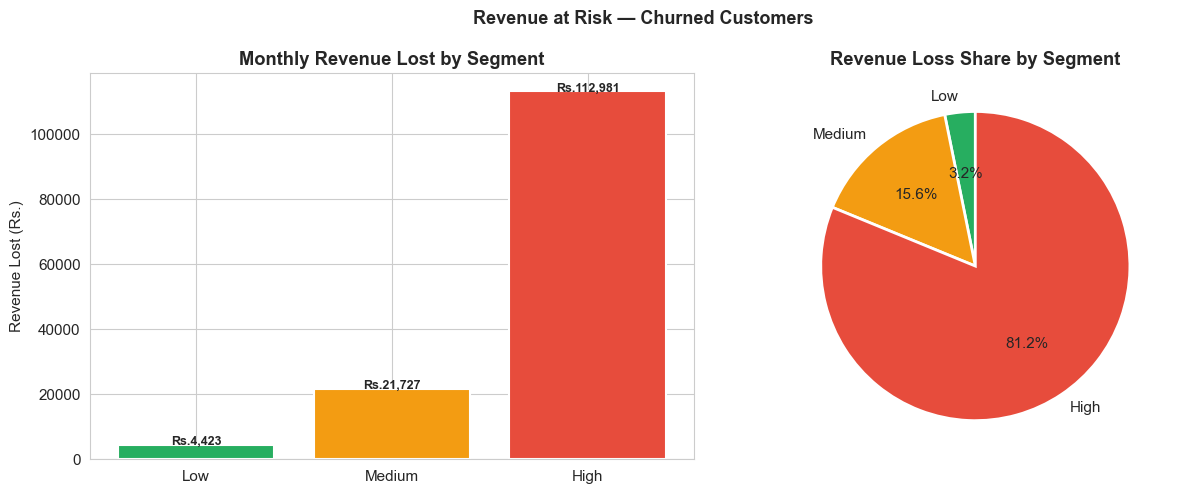

In [5]:
if 'RevenueCategory' in df.columns:
    rev_risk = (df[df['Churn']==1]
                .groupby('RevenueCategory')['MonthlyCharges']
                .agg(['sum','count'])
                .rename(columns={'sum':'Revenue Lost','count':'Customers'}))
    rev_risk = rev_risk.reindex(['Low','Medium','High'])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = ['#27ae60','#f39c12','#e74c3c']

    bars = axes[0].bar(rev_risk.index, rev_risk['Revenue Lost'],
                       color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, rev_risk['Revenue Lost']):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                     f'Rs.{val:,.0f}', ha='center', fontweight='bold', fontsize=9)
    axes[0].set_title('Monthly Revenue Lost by Segment', fontweight='bold')
    axes[0].set_ylabel('Revenue Lost (Rs.)')

    axes[1].pie(rev_risk['Revenue Lost'], labels=rev_risk.index,
                autopct='%1.1f%%', colors=colors,
                startangle=90, wedgeprops=dict(edgecolor='white',linewidth=2))
    axes[1].set_title('Revenue Loss Share by Segment', fontweight='bold')

    plt.suptitle('Revenue at Risk — Churned Customers', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## 5. Churn Probability Distribution (ML)

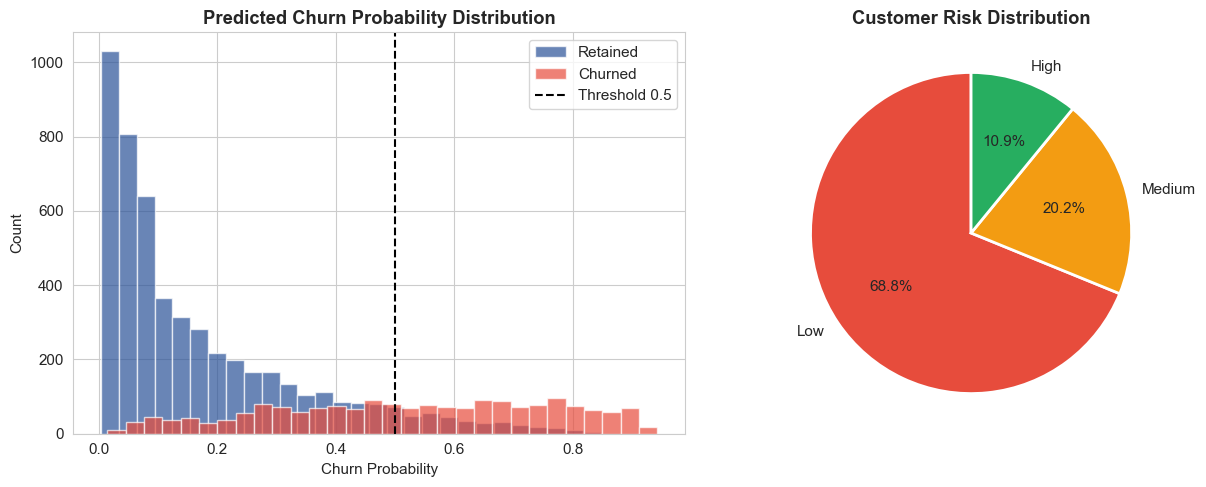

High risk (>65% prob): 769
Medium risk (35-65%): 1426
Low risk (<35%): 4848


In [6]:
if HAS_ML:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Histogram of probabilities
    axes[0].hist(df[df['Churn']==0]['ChurnProbability'], bins=30,
                 alpha=0.7, color='#2a5298', label='Retained', edgecolor='white')
    axes[0].hist(df[df['Churn']==1]['ChurnProbability'], bins=30,
                 alpha=0.7, color='#e74c3c', label='Churned', edgecolor='white')
    axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
    axes[0].set_title('Predicted Churn Probability Distribution', fontweight='bold')
    axes[0].set_xlabel('Churn Probability'); axes[0].set_ylabel('Count')
    axes[0].legend()

    # Risk level pie
    risk_counts = df['ChurnRisk'].value_counts()
    axes[1].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
                colors=['#e74c3c','#f39c12','#27ae60'],
                startangle=90, wedgeprops=dict(edgecolor='white',linewidth=2))
    axes[1].set_title('Customer Risk Distribution', fontweight='bold')

    plt.tight_layout(); plt.show()
    print('High risk (>65% prob):', (df['ChurnRisk']=='High').sum())
    print('Medium risk (35-65%):', (df['ChurnRisk']=='Medium').sum())
    print('Low risk (<35%):', (df['ChurnRisk']=='Low').sum())
else:
    print('ML scores not available. Run pipeline first: python main.py --no-load')

## 6. Retention Offer Distribution

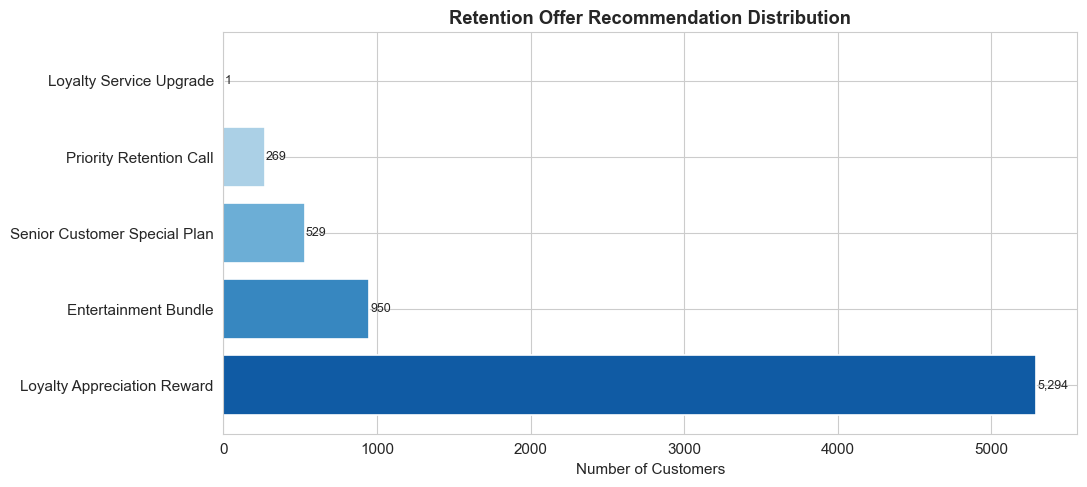

In [7]:
if 'OfferTitle' in df.columns:
    offer_stats = df['OfferTitle'].value_counts()

    plt.figure(figsize=(11, 5))
    bars = plt.barh(offer_stats.index, offer_stats.values,
                    color=sns.color_palette('Blues_r', len(offer_stats)),
                    edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, offer_stats.values):
        plt.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
    plt.title('Retention Offer Recommendation Distribution', fontweight='bold')
    plt.xlabel('Number of Customers')
    plt.tight_layout(); plt.show()
else:
    print('Offer data not available. Run pipeline first.')

## 7. Model Performance Summary (from saved metrics)

Best Model: GradientBoosting

             Model  Accuracy     F1  ROC-AUC
      RandomForest    0.7644 0.6336   0.8298
  GradientBoosting    0.7928 0.5576   0.8321
LogisticRegression    0.7317 0.6054   0.8234


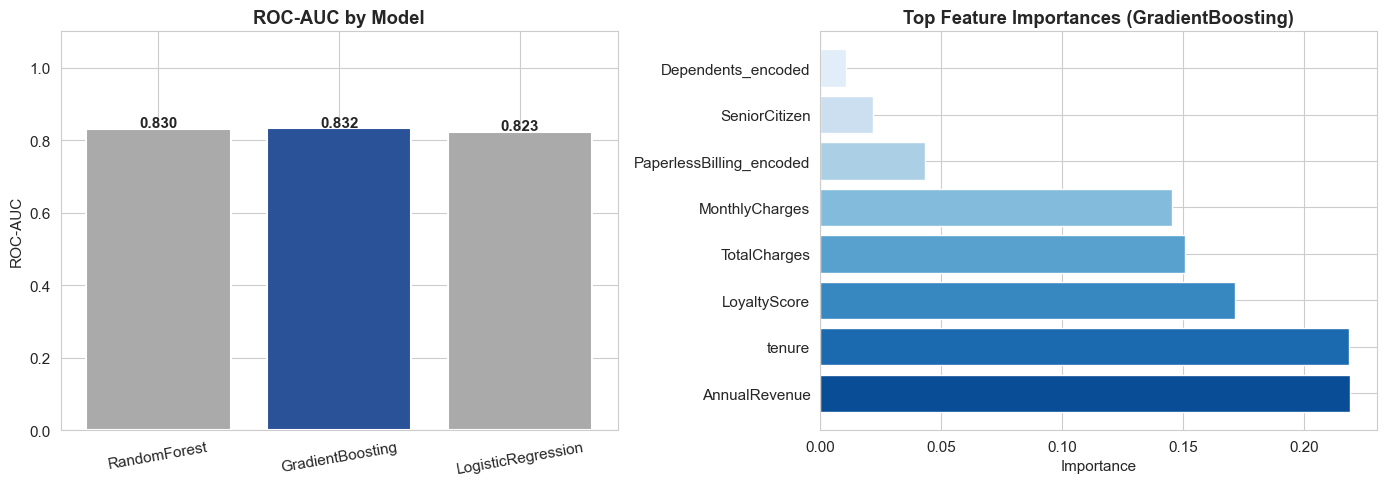

In [8]:
METRICS_PATH = '../models/model_metrics.json'

if os.path.exists(METRICS_PATH):
    with open(METRICS_PATH) as f:
        metrics = json.load(f)

    best  = metrics['best_model']
    mres  = metrics['model_results']
    fimp  = metrics['feature_importance']

    print(f'Best Model: {best}\n')

    # Metrics table
    rows = []
    for m, v in mres.items():
        rows.append({'Model':m,'Accuracy':v['accuracy'],'F1':v['f1'],'ROC-AUC':v['roc_auc']})
    print(pd.DataFrame(rows).to_string(index=False))

    # Charts
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC-AUC bar
    names = list(mres.keys())
    aucs  = [mres[n]['roc_auc'] for n in names]
    bar_colors = ['#2a5298' if n==best else '#aaaaaa' for n in names]
    bars = axes[0].bar(names, aucs, color=bar_colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, aucs):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{val:.3f}', ha='center', fontweight='bold')
    axes[0].set_title('ROC-AUC by Model', fontweight='bold')
    axes[0].set_ylim(0, 1.1); axes[0].set_ylabel('ROC-AUC')
    axes[0].tick_params(axis='x', rotation=10)

    # Feature importance
    if fimp:
        fi_df = pd.DataFrame(list(fimp.items()), columns=['Feature','Importance']).head(8)
        axes[1].barh(fi_df['Feature'], fi_df['Importance'],
                     color=sns.color_palette('Blues_r', len(fi_df)), edgecolor='white')
        axes[1].set_title(f'Top Feature Importances ({best})', fontweight='bold')
        axes[1].set_xlabel('Importance')

    plt.tight_layout(); plt.show()
else:
    print('Model metrics not found. Run: python main.py --no-load')

## 8. Key Business Insights

| # | Insight | Impact |
|---|---|---|
| 1 | Month-to-month customers churn at ~43% | Highest priority for contract upgrade offers |
| 2 | Electronic check users have highest churn | Auto-pay cashback can reduce this |
| 3 | Fiber optic users churn more than DSL | Tech support bundle reduces friction |
| 4 | First-year customers churn most | Onboarding and early engagement programs needed |
| 5 | High monthly charges correlate with churn | Loyalty discounts for high-value customers |
| 6 | Senior citizens at higher risk | Dedicated senior plan reduces churn |
| 7 | Long-tenure customers are loyal | Reward them to maintain retention |

## 9. Project Architecture Summary

```
Raw CSV (7,043 rows)
    ↓  extract.py       Validate + Backup
    ↓  transform.py     Clean + Encode + Engineer Features
    ↓  train_model.py   RandomForest + XGBoost + LogReg → Best Model
    ↓  predict.py       ChurnProbability + ChurnRisk per customer
    ↓  recommend.py     Personalised Retention Offer per customer
    ↓  load.py          PostgreSQL (two tables)
    ↓  app.py           Streamlit Dashboard (4 pages + Auth)
```

---
**Project Complete — Divyesh Joshi | MC24097 | MCA-II Sem IV | SPPU 2025-26**